# Day 14 In-Class Assignment: Approval Ratings


### <p style="text-align: right;"> &#9989; Put your name here.</p>

#### <p style="text-align: right;"> &#9989; Put your group member names here.</p>

### Update posted March 4, 2024 after class

This module was way too long so we didn't finish in class. So the plan is:
- Prior to Wednesday's class, you should have completed up to (not including) the section called `Linear Regression`. 
- There is no pre-class assignment submission required. 

## How popular/unpopular is Joe Biden?

<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse801-supplemental/main/Day-14/popularity.png" width=1200px>

## Fitting approval rating data and making predictions

In this assignment we're going to look at how we might use a meaningful model to understand data.

The **learning goals** of the assignment are to:
* Discuss the role that models play in our understanding of the world around us and how models can be used to make predictions.
* Practice using the SciPy `curve_fit()` function to fit a specific model to data
* Practice using resources like ChatGPT
* Interpret the results of our best fit model
* Use our best fit model to calculate new values and forecast future behavior

### Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the notebook. The assignment is due at the end of class.

The following FiveThirtyEight article uses this data and updates it regularly: https://projects.fivethirtyeight.com/biden-approval-rating/

---
### Loading and viewing the data

On the class website, there is a file named `biden_ratings_2023.csv` make sure you download that file and put it in the same place as this jupyter notebook. This is a dataset containing the results of different polls about Biden's approval rating. 

&#9989; **Task**: Using Pandas, **read in the data file**  and save the numpy array as `data_2023`. **Look at the data** by displaying the dataframe or information about the dataframe using some of the Pandas functions you've learned up to this point. 

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Put your code to read in the dataset and display the first few rows

&#9989; **Task:** Answer these questions

1. How many columns and rows does the dataset have ?
2. What is the `type` of the `start_date` and `end_date` columns?
3. What information is contained in the `yes` and `no` columns?

<font size=+3>&#9998;</font> *Put your answers here*

In [4]:
# Put any code you might need to answer the questions here.

The code below makes a **scatter plot** of approval (`yes` column) and disapproval (`no` column) ratings vs `end_date`. 

&#9989; **Task:** Run the code. What do you notice? 

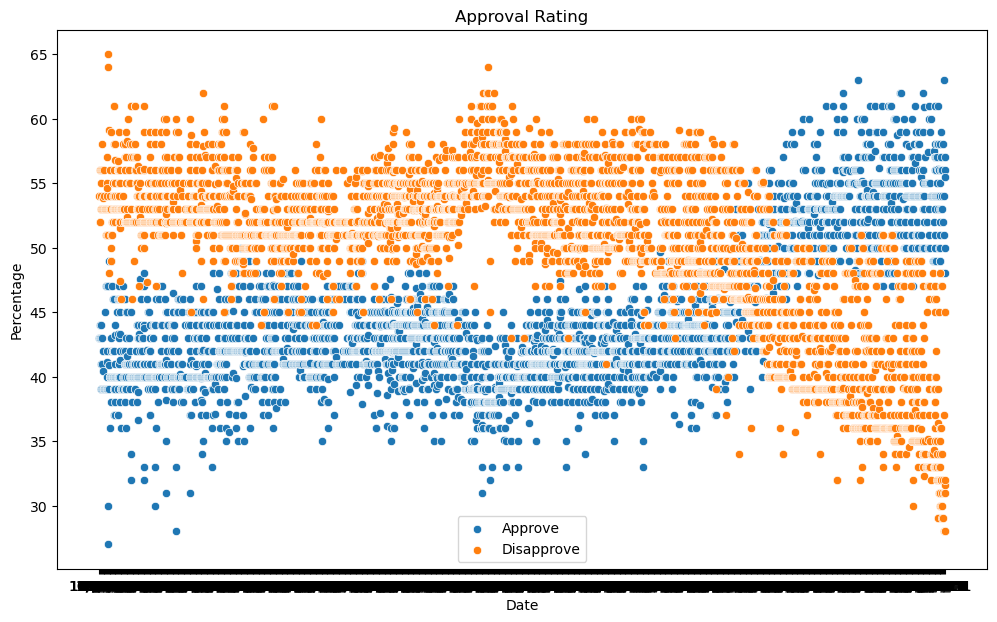

In [6]:
fig, ax = plt.subplots(1,1, figsize = (12,7))
# Scatter plot for 'Yes' column
sns.scatterplot(data = data_2023, x = "end_date", y = "yes", label = 'Approve', ax = ax)
# Scatter plot for 'No' column
sns.scatterplot(data = data_2023, x = "end_date", y = "no", label = 'Disapprove',  ax = ax)
# Setting the title and labels
_ = ax.set( title = "Approval Rating", xlabel = "Date", ylabel = "Percentage")


<font size=+3>&#9998;</font> *Put your answers here*

Mmmh that plot doesn't look that useful. The first thing you may notice is that the plot looks reversed from the one shown at the top of the notebook. Biden's disapproval actually increases over time while it appears to descrease in the plot we made. The second thing is that the $x$-axis is pretty messy. That is because `end_date` is a `string` and `seaborn` doesn't recognize it as a date. Fortunately, `pandas` has a specific `type` for dates and times. 

&#9989; **Task:** Using [`pandas.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) convert the column `end_date` to a `datetime` object. Then **remake the plot**.

**IMPORTANT:** Read the documentation and look for a `format` option, you need to know how the dates are stored in the dataset.

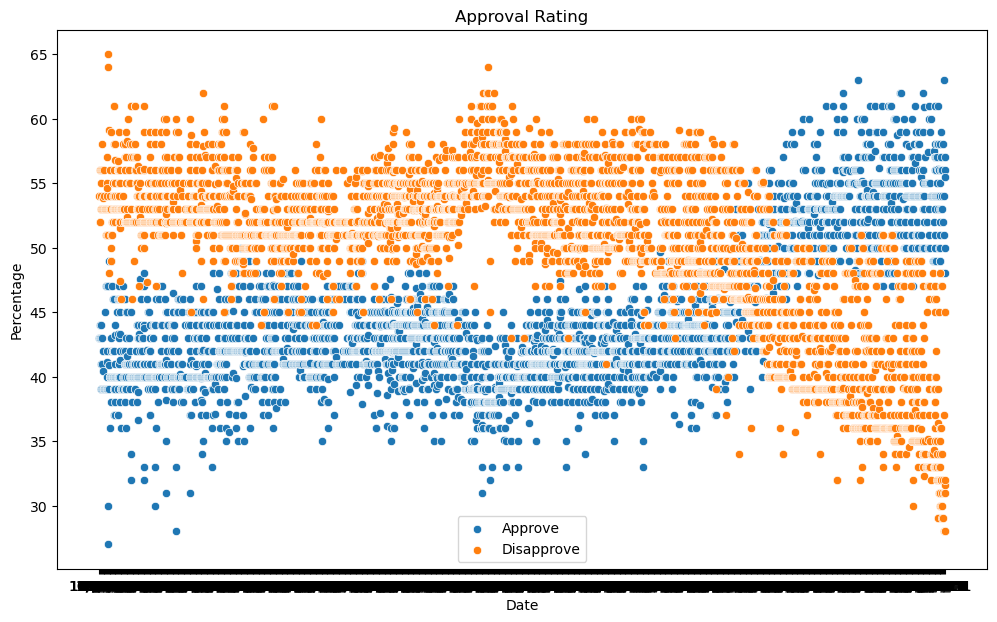

In [7]:
# Put your code to convert 'end_date' column to pandas datetime format with the specific format here
...

fig, ax = plt.subplots(1,1, figsize = (12,7))
# Scatter plot for 'Yes' column
sns.scatterplot(data = data_2023, x = "end_date", y = "yes", label = 'Approve', ax = ax)
# Scatter plot for 'No' column
sns.scatterplot(data = data_2023, x = "end_date", y = "no", label = 'Disapprove',  ax = ax)
# Setting the title and labels
_ = ax.set( title = "Approval Rating", xlabel = "Date", ylabel = "Percentage")


&#9989; **Question:** What does the option `ax` do inside the `scatterplot` function ?

<font size=+3>&#9998;</font> *Put your answers here*

As you can see the dataset contains the results of multiple pollsters. 

&#9989; **Task:** Choose your favorite pollster and using a mask select only their poll results and save them into a dataframe with a different name. Then, display the first 10 rows of `end_date`, `yes`, and `no` only

In [10]:
# Put your code here

As you can see the data is in descending order, for our code later, we need to reverse the order so that the dates are increasing. 

&#9989; **Task:** Ask [ChatGPT](https://chat.openai.com) for the code to reverse the order of your dataset such that the date column is in ascending order (or write the code yourself if you know how). Then, display the first 10 rows of `end_date`, `yes`, and `no` only

In [12]:
# Put your code or ChatGPT's code here. Remember to check 
# ChatGPT's answers! 

Now the data is in the correct order, but it appears that polls results are taken only every few days. Let's try to fix that by filling in the extra days.

&#9989; **Task:** Ask [ChatGPT](chat.openai.com) how to create a new array called `days_since_first` which has the same length as your data, where each entry is the number of days in that entry
 since the first row. For example, if the first row has `2021-01-21` and a later entry has `2021-02-03`, then the new array should have a `13` in that later entry. Print out the new array to make sure ChatGPT did what you wanted. 

In [14]:
# Put ChatGPT's code here (or your own)

&#9989; **Task:** Split the array `days_since_first` into two; one array containing the first 80% of the data (which we will use for training/creating a model) and one with the remaining 20% (which we will use for testing the quality of that model). You can ask ChatGPT if you want some help. Call the first array `training_time` and the second array `testing_time`. 

Split the `yes` and `no` columns in the same way and give them appropriate names.

Print out the arrays and make sure they are correct 

In [16]:
# Put your code here 

---
### Linear Regression

Ok. We are now ready to model!

As a first pass, your goal is to produce a fit to the data using a linear model, _i.e._ $y = a x + b$ and a quadratic model, _i.e._ $y = ax^2 + bx + c$. 

&#9989; **Task:** Create a linear fit to the disapproval ratings (or approval ratings, your choice) using `curve_fit`. Make a plot of the disapproval (approval) data along with the best fit line. Once you have this working, do the same for a quadratic model.

**IMPORTANT:** Recall that `end_date` is not a number, but a `datetime` object. The probelm is that `curve_fit` accepts only numbers, but this is why we created the `days_since_first` array to begin with. Use the `training_set` as your independent variable. Make sure the arrays are the same length.

In [18]:
#Put your code here


&#9989; **Task:** What are the parameters for your best fit? **Print out those parameter values**. *Something to think about*: once you have your best fit parameters, what's the easiest way to use those values to plot your model? 

In [20]:
# Put your code here

### Fitting with an arbitrary function

What if we think that the data follows a function with a form that is different than that of a polynomial? This is where curvefit comes in.  Let's try fitting the approval and disapproval ratings using a cosine function, the similar to the one from our pre-class assignment:

$$ f(x) = \frac{A}{1 + C \exp(- B x) } $$

&#9989; **Task:** Define a python function that computes the above mathematical function and then **use that function to fit the data using SciPy's `curve_fit` function**. Plot the resulting fit along with the data for just the disapproval ratings.

Is $f(x)$ a good choice for fitting the data? If not, is there a reason why this is the case? Does it mean the function is a bad choice or is the `curve_fit` function just not returning sensible results?

In [22]:
# Put your code here

When you first try running `curve_fit()`, you might get a warning and you might get results that don't make sense. Sometimes `curve_fit()` will fail to find a good fit if the initial guess for the best fit parameters is too far off. How would you fix this? Look at the [documentation for `curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), especially the `p0` argument, and see if you and your group can figure out how to overcome this issue. What might be reasonable starting guesses for the initial values of `A,B,C`? **Hint**: revisit the plot from above and the parameters that were used to make those models.

&#9989; **Task:** Rerun your code above, but using new initial values.

---
## Comparing our fit to new data

One of the useful features of coming up with a best fit model to a set of data is that we can use that model to make predictions about what new data might look like.

&#9989; **Task:** Using your linear fit and another best fit of your choosing, make a plot that predicts the test dataset. Specifically, we just want to extend the best fit lines an additional ~400 days.

In [25]:
# Put your code here

### How well do our models do?

It is now time to use our test data. 

&#9989; **Task:** Plot the test data on the plot above. **How well do your models fit the data?** Can you think of a way that would allow you to quantify how "good" your fit is?

In [27]:
# Put your code here

*Put your answer here*

### Fitting all of the data

Sometimes, when we acquire new data, we might have to revise our model if the new data is not supported by the model. This is a common practice in modeling and data science. If you trust the data and your model no longer matches the data, then something must have been wrong about your model!

&#9989; Now that you have all of the data, trying finding the best fit to the full dataset. **What sort of model did you choose? How does it compare to your original fit to only part of the data?**


In [29]:
# Put your code here

*Put your answer here*

---

## Congratulations, you're done!

Submit this assignment by uploading your notebook to the course Desire2Learn web page.  Go to the "In-Class Assignments" folder, find the appropriate submission link, and upload everything there. Make sure your name is on it!

&#169; Copyright 2023,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.